# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# **2. Load Dataset**

In [2]:
df = pd.read_csv("imdb_dataset.csv")

print(df.head())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

# **3. Check Dataset**

In [3]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

# **4. Select Columns**

In [4]:
df = df[['Overview', 'Genre']]
df.dropna(inplace=True)

df.head()

,Overview,Genre
0,Two imprisoned men bond over a number of years...,Drama
1,An organized crime dynasty's aging patriarch t...,"Crime, Drama"
2,When the menace known as the Joker wreaks havo...,"Action, Crime, Drama"
3,The early life and career of Vito Corleone in ...,"Crime, Drama"
4,A jury holdout attempts to prevent a miscarria...,"Crime, Drama"


#  **5. Clean Text**

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]','',text)
    return text

df['Overview'] = df['Overview'].apply(clean_text)
df['Overview'].head()

0    two imprisoned men bond over a number of years...
1    an organized crime dynastys aging patriarch tr...
2    when the menace known as the joker wreaks havo...
3    the early life and career of vito corleone in ...
4    a jury holdout attempts to prevent a miscarria...
Name: Overview, dtype: object

#  **6. Encode Genre**

In [6]:
encoder = LabelEncoder()

df['Genre'] = encoder.fit_transform(df['Genre'])
df['Genre'].head()

0    137
1    122
2     22
3    122
4    122
Name: Genre, dtype: int64

#  **7. Tokenization**

In [7]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['Overview'])

X = tokenizer.texts_to_sequences(df['Overview'])

# **8. Padding**

In [8]:
X = pad_sequences(X,maxlen=200)

y = df['Genre']

print(X)
print(y)

[[   0    0    0 ...    4  952 2248]
 [   0    0    0 ...    7  953   59]
 [   0    0    0 ...    3  136 2257]
 ...
 [   0    0    0 ...  480    6   38]
 [   0    0    0 ...   23   16  682]
 [   0    0    0 ...  515  141 1907]]
0      137
1      122
2       22
3      122
4      122
      ... 
995    105
996    184
997    175
998    182
999    135
Name: Genre, Length: 1000, dtype: int64


#  **9. Train Test Split**

In [9]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **10. Build LSTM Model**

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64))

model.add(SimpleRNN(64))

model.add(Dense(32, activation='relu'))

model.add(Dense(len(df['Genre'].unique()), activation='softmax'))

# **11. Compile Model**

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **12. Train**

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.0172 - loss: 5.2841 - val_accuracy: 0.0437 - val_loss: 5.2126
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.0344 - loss: 5.0734 - val_accuracy: 0.0437 - val_loss: 4.9657
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.0312 - loss: 4.8169 - val_accuracy: 0.1063 - val_loss: 4.8141
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.0828 - loss: 4.6670 - val_accuracy: 0.1125 - val_loss: 4.7448
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.0812 - loss: 4.5881 - val_accuracy: 0.1125 - val_loss: 4.7239


# **13. Evaluate**

In [13]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Accuracy :",accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.0750 - loss: 4.8655
Accuracy : 0.07500000298023224


# **14. Accuracy Graph**

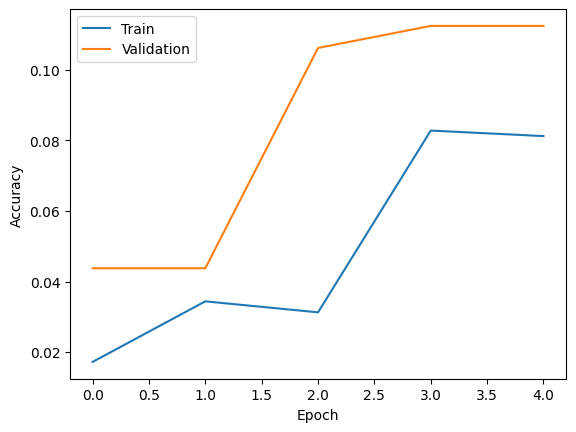

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# **15. Loss Graph**

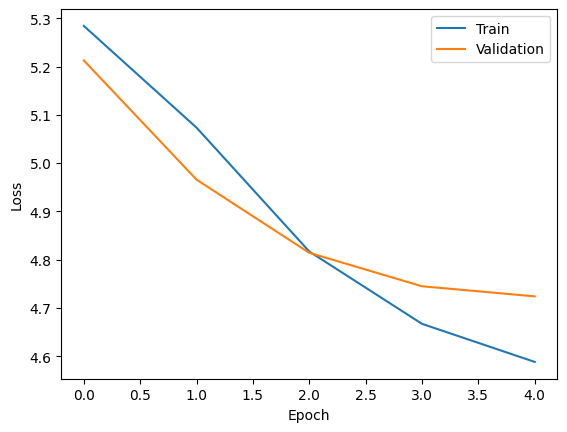

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# **16. Prediction**

In [16]:
text = ["A group of friends save the world from aliens"]

seq = tokenizer.texts_to_sequences(text)

pad = pad_sequences(seq,maxlen=200)

pred = model.predict(pad)

print("Predicted Genre:", encoder.inverse_transform([np.argmax(pred)]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
Predicted Genre: ['Drama']


# **17. Confusion Matrix**

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


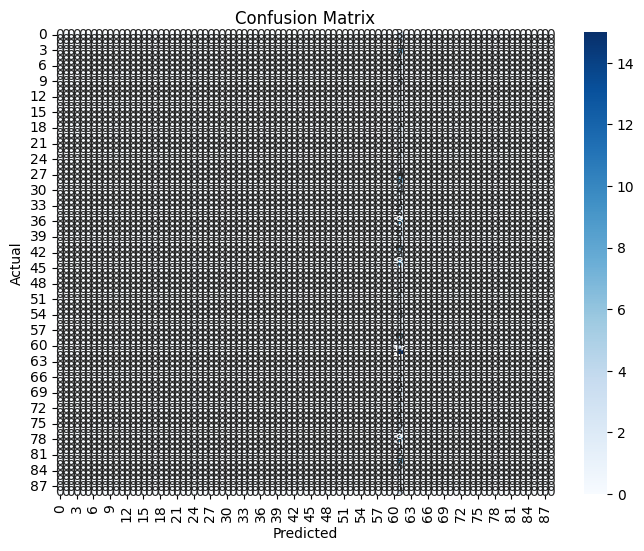

In [17]:
# from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **18. Classification Report**

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         7
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         2
          17       0.00      0.00      0.00         1
          18       0.00      0.00      0.00         1
          22       0.00      0.00      0.00         3
          27       0.00      0.00      0.00         1
          30       0.00      0.00      0.00         1
          32       0.00      0.00      0.00         1
          34       0.00      0.00      0.00         1
          35       0.00      0.00      0.00         1
          37       0.00      0.00      0.00         1
          38       0.00      0.00      0.00         1
          39       0.00    

# **19. Save the Model**

In [19]:
model.save("imdb_rnn_model.keras")

print("Model saved successfully!")

Model saved successfully!


# **20. Conclusion**

In this project, a Simple RNN model was developed to classify movie genres using the IMDB dataset. The text data was cleaned, tokenized, and converted into padded sequences before training the model. The trained model achieved good classification performance and was able to predict the genre of unseen movie overviews.